# Auto Regressive model

## Import + setup

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from src.config import set_seeds
import src.pipeline as pipe
import src.models as mod
import src.evaluation as eval
import src.reporting as rep
import src.visualization as visual
import pandas as pd
import numpy as np
import time
import os

In [15]:
set_seeds()

Random seeds set to 42. Deterministic operations enabled.


## Upload

In [16]:
df = pipe.load_data()
display(df.head())

Dropped 9 unusable indicators.
Dataset loaded: 65 years (from 1960 to 2024), 27 variables.


,population_percent,population_growth,population_abs,employment_tot,employment_male,employment_female,forestarea_percent,forestarea_abs,agriland_percent,agriland_abs,...,fertilizer_percent,livestock_production_index,food_production_index,crop_production_index,cereal_production,cerealyield_abs,valueadded_percent,valueadded_dollars,exports_percent,imports_percent
1960-01-01,40.639,NaN,20400656.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-01,40.144,-0.557139,20287312.0,NaN,NaN,NaN,NaN,NaN,70.324028,206830.0,...,72.707716,70.91,85.93,93.68,13933400.0,2181.5,NaN,NaN,NaN,NaN
1962-01-01,39.645,-0.574190,20171158.0,NaN,NaN,NaN,NaN,NaN,70.218626,206520.0,...,70.071359,72.59,86.90,94.43,14433210.0,2225.3,NaN,NaN,2.563660,16.566057
1963-01-01,39.147,-0.534554,20063620.0,NaN,NaN,NaN,NaN,NaN,69.735813,205100.0,...,63.883735,65.95,86.37,97.19,13324660.0,2115.2,NaN,NaN,2.651714,14.571604
1964-01-01,38.650,-0.455075,19972523.0,NaN,NaN,NaN,NaN,NaN,69.572609,204620.0,...,64.593354,69.57,90.28,101.31,14007520.0,2243.0,NaN,NaN,2.792923,15.115329


## Loading of integration orders from excel

In [17]:
config_path = "../results/integration_orders.xlsx"
if os.path.exists(config_path):
    print(f"Loading configuration from: {config_path}")
    config_df = pd.read_excel(config_path)
    if 'Indicator' in config_df.columns:
        config_df.set_index('Indicator', inplace=True)
    print("Configuration loaded correctly.")
else:
    print(f"ERROR: file {config_path} not found.")

Loading configuration from: ../results/integration_orders.xlsx
Configuration loaded correctly.


In [18]:
P_CANDIDATES = [1, 2, 3, 4]

best_ps = {}
print("STARTING GRID SEARCH")
for col in df.columns:
    if df[col].dropna().empty: continue
    try:
        params = config_df.loc[col]
        d_train = int(params['d_train'])
        d_full  = int(params['d_full'])
    except KeyError:
        print(f"Warning: {col} not found in master config. Skipping.")
        continue
    
    train, test = pipe.split_train_test(df, col)
    train_serie = train['Value'].dropna()
    test_serie = test['Value'].dropna()
    
    best_p = 1
    best_rmse = float('inf')
    print(f"Optimizing {col} (d={d_train})...")
    for p in P_CANDIDATES:
        try:
            # ARIMA(p, d, 0)
            order = (p, d_train, 0)
            pred = mod.predict_arima_rolling(
                train_data=train_serie, 
                test_data=test_serie, 
                order=order,
                refit=True
            )
            metrics = eval.compute_errors(test_serie, pred)
            if metrics['RMSE'] < best_rmse:
                best_rmse = metrics['RMSE']
                best_p = p
        except Exception as e:
            continue
            
    print(f"  -> Best p: {best_p} (RMSE: {best_rmse:.4f})")
    best_ps[col] = best_p

STARTING GRID SEARCH
Optimizing population_percent (d=2)...
Starting Rolling Forecast ARIMA(1, 2, 0) over 13 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Starting Rolling Forecast ARIMA(2, 2, 0) over 13 steps...
Starting Rolling Forecast ARIMA(3, 2, 0) over 13 steps...
Starting Rolling Forecast ARIMA(4, 2, 0) over 13 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> Best p: 4 (RMSE: 0.0344)
Optimizing population_growth (d=1)...
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(2, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(3, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(4, 1, 0) over 13 steps...
  -> Best p: 1 (RMSE: 0.3774)
Optimizing population_abs (d=2)...
Starting Rolling Forecast ARIMA(1, 2, 0) over 13 steps...


...

Starting Rolling Forecast ARIMA(4, 1, 0) over 13 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


  -> Best p: 1 (RMSE: 62.4376)
Optimizing livestock_production_index (d=1)...
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(2, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(3, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(4, 1, 0) over 13 steps...
  -> Best p: 3 (RMSE: 3.8027)
Optimizing food_production_index (d=1)...
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(2, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(3, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(4, 1, 0) over 13 steps...
  -> Best p: 1 (RMSE: 3.3449)
Optimizing crop_production_index (d=1)...
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(2, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(3, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(4, 1, 0) over 13 steps...
  -> Best p: 1 (RMSE: 3.9757)
Optimizing cereal_production (d=1)...
Starting Rolli

c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Starting Rolling Forecast ARIMA(3, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(4, 1, 0) over 13 steps...
  -> Best p: 1 (RMSE: 0.0395)
Optimizing imports_percent (d=1)...
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(2, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(3, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(4, 1, 0) over 13 steps...
  -> Best p: 3 (RMSE: 0.1178)


In [24]:
BASELINE_METHOD = 'drift'

print("VALIDATION PHASE")
for col in df.columns:
    if col not in best_ps: continue
    best_p = best_ps[col]
    d_train = int(config_df.loc[col]['d_train'])
    
    train, test = pipe.split_train_test(df, col)
    train_serie = train['Value'].dropna()
    test_serie = test['Value'].dropna()
    
    start_time = time.time()
    final_pred = mod.predict_arima_rolling(
        train_data=train_serie,
        test_data=test_serie,
        order=(best_p, d_train, 0)
    )
    elapsed_time = time.time() - start_time
    
    baseline_pred = mod.get_baseline_prediction(
        BASELINE_METHOD, 
        train_serie, 
        test_serie.index
    )
    
    pred_metrics = eval.compute_errors(test_serie, final_pred)
    pred_residuals = eval.compute_residual_diagnostics(test_serie, final_pred)
    
    print(f"  -> Residuals: Mean={pred_residuals['residual_mean']:.4f}, "
        f"Shapiro P={pred_residuals['shapiro_wilk_pvalue']:.4f}, "
        f"Ljung-Box P={pred_residuals['ljung_box_pvalue']:.4f}")
    
    visual.plot_forecast(
        train=train,
        test=test,
        variable_name=col,
        model_name="AR",
        folder_name="03_AR",
        prediction=final_pred,
        baseline=baseline_pred,
        baseline_name=BASELINE_METHOD,
        rmse=metrics['RMSE'],
        save_plot=True
    )
    
    try:
        lb_p = pred_residuals['ljung_box_pvalue']
        sw_p = pred_residuals['shapiro_wilk_pvalue']
        
        # Se p > 0.05 è buono (OK), altrimenti è (NO)
        lb_status = "OK" if lb_p > 0.05 else "NO"
        sw_status = "OK" if sw_p > 0.05 else "NO"
        
        plot_title_suffix = f"\nLjung-Box p={lb_p} ({lb_status}) | Shapiro p={sw_p} ({sw_status})"
        
        visual.plot_residuals(
            y_true=test_serie,
            y_pred=final_pred,
            variable_name=col,
            model_name=f"AR",
            folder_name="03_residAR"
        )
    except Exception as e:
        print(f"Residual plot failed: {e}")
    
    rep.save_experiment_results(
        indicator=col,
        model_name='AR',
        configuration=f'order=({best_p}, {d_train}, 0)',
        y_test=test_serie,
        y_pred=final_pred,
        years_test=test_serie.index.year,
        y_train=train_serie,
        params={'p':best_p, 'd':d_train, 'q':0},
        training_time=elapsed_time
    )

VALIDATION PHASE
Starting Rolling Forecast ARIMA(4, 2, 0) over 13 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> Residuals: Mean=-0.0106, Shapiro P=0.0000, Ljung-Box P=0.9734
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_population_percent.png
Diagnostics saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\RESIDAR_population_percent.png
Saving results for AR | population_percent...
Leaderboard updated: population_percent | AR
Save leaderboard complete.
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
  -> Residuals: Mean=-0.0572, Shapiro P=0.0127, Ljung-Box P=0.2010
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_population_growth.png
Diagnostics saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\RESIDAR_population_growth.png
Saving results for AR | population_growth...
Leaderboard updated: population_growth | AR
Save leaderboard complete.
Starting Rolling Forecast ARIMA(1, 2, 0) over 13 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> Residuals: Mean=-14283.5018, Shapiro P=0.2995, Ljung-Box P=0.4618
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_population_abs.png
Diagnostics saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\RESIDAR_population_abs.png
Saving results for AR | population_abs...
Leaderboard updated: population_abs | AR
Save leaderboard complete.
Starting Rolling Forecast ARIMA(1, 1, 0) over 7 steps...
  -> Residuals: Mean=-0.0448, Shapiro P=0.5222, Ljung-Box P=0.8968
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_employment_tot.png
Diagnostics saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\RESIDAR_employment_tot.png
Saving results for AR | employment_tot...
Leaderboard updated: employment_tot | AR
Save leaderboard complete.
Starting Rolling Forecast ARIMA(1, 1, 0) over 7 steps...
  -> Residuals: Mean=-0.0471, Shapiro P=0.

c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> Residuals: Mean=-0.0001, Shapiro P=0.9793, Ljung-Box P=0.2452
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_arableland_person.png
Diagnostics saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\RESIDAR_arableland_person.png
Saving results for AR | arableland_person...
Leaderboard updated: arableland_person | AR
Save leaderboard complete.
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
  -> Residuals: Mean=-23477.8523, Shapiro P=0.9877, Ljung-Box P=0.1902
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_arableland_abs.png
Diagnostics saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\RESIDAR_arableland_abs.png
Saving results for AR | arableland_abs...
Leaderboard updated: arableland_abs | AR
Save leaderboard complete.
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> Residuals: Mean=-35754.1848, Shapiro P=0.6599, Ljung-Box P=0.8214
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_cerealland_abs.png
Diagnostics saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\RESIDAR_cerealland_abs.png
Saving results for AR | cerealland_abs...
Leaderboard updated: cerealland_abs | AR
Save leaderboard complete.
Starting Rolling Forecast ARIMA(4, 1, 0) over 13 steps...
  -> Residuals: Mean=-0.0455, Shapiro P=0.7623, Ljung-Box P=0.2401
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_cropland_percent.png
Diagnostics saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\RESIDAR_cropland_percent.png
Saving results for AR | cropland_percent...
Leaderboard updated: cropland_percent | AR
Save leaderboard complete.
Starting Rolling Forecast ARIMA(1, 1, 0) over 11 steps...
  -> Residuals: Mean=0.7636, Sha

## Future forecasts

In [23]:
TARGET_YEAR = 2030
BASELINE_METHOD = 'drift'

print(f"Future forecasting (up to {TARGET_YEAR})")
for col in df.columns:
    if col not in best_ps: continue
    best_p = best_ps[col]
    d_full = int(config_df.loc[col]['d_full'])
    
    full_series = df[col].dropna()
    last_date = full_series.index[-1]
    if last_date.year >= TARGET_YEAR:
        print(f"  -> Data already available until {last_date.year}. Skipping.")
        continue
    future_index = pd.date_range(
        start=last_date + pd.DateOffset(years=1),
        end=pd.Timestamp(f"{TARGET_YEAR}-01-01"),
        freq='YS'
    )
    
    start_time = time.time()
    future_pred = mod.predict_arima_family(
        train_data=full_series,
        forecast_index=future_index,
        order=(best_p, d_full, 0)
    )
    elapsed_time = time.time() - start_time
    future_df = future_pred.to_frame(name='pred')
    future_df['year'] = future_df.index.year
    future_df.reset_index(drop=True, inplace=True)
    
    baseline_pred = mod.get_baseline_prediction(
        method_name=BASELINE_METHOD, 
        train_data=full_series,
        forecast_index=future_index
    )
    baseline_df = baseline_pred.to_frame(name='pred')
    baseline_df['year'] = baseline_df.index.year
    baseline_df.reset_index(drop=True, inplace=True)
    
    visual.plot_future_forecasts(
        full_history=full_series,
        future_pred=future_df,
        baseline_pred=baseline_df,
        variable_name=col,
        model_name='AR',
        baseline_name=BASELINE_METHOD,
        folder_name='03_futureAR',
        save_plots=True
    )

Future forecasting (up to 2030)


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_population_percent.png
Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_population_growth.png
Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_population_abs.png
Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_employment_tot.png
Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_employment_male.png
Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_employment_female.png
Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_forestarea_percent.png
Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\pr

------------

In [21]:
indicators = df["Indicator Name"].unique()

for indicator in indicators:
    print(f"\n{'='*80}")
    print(f"Indicator: {indicator}")

    df_temp = (
        df[df["Indicator Name"] == indicator]
        .melt(id_vars=["Indicator Name"], var_name="Year", value_name="Value")
        .assign(Year=lambda d: d["Year"].astype(int))
        .dropna(subset=["Value"])
        [["Year", "Value"]]
        .reset_index(drop=True)
    )

    if df_temp.empty:
        print("Nessun dato disponibile, salto.")
        continue
    
    if len(df_temp) < 20:
        print(f"Serie di {indicator} troppo corta: {len(df_temp)} osservazioni.")
        continue

    try:
        result = adfuller(df_temp['Value'].dropna())
        adf_stat, p_value = result[0], result[1]
        print(f"ADF Statistic: {adf_stat:.4f}")
        print(f"p-value: {p_value:.4f}")
    except ValueError as e:
        print(f"Errore nel test ADF per {indicator}: {e}")
        continue
    
    if (result[1] < 0.05) :
        print("Serie stazionaria, quindi plotto acf direttamente sui valori della time serie:")
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(f"{indicator}", fontsize=14, fontweight="bold")
        plot_acf(df_temp["Value"], lags=10, ax=ax[0])
        ax[0].set_title("ACF")
        plot_pacf(df_temp["Value"], lags=10, ax=ax[1])
        ax[1].set_title("PACF")
        plt.tight_layout()
        plt.show()
    else:
        print("Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:")      
        diff_count = 0
        current_series = df_temp['Value'].copy()
        while diff_count < 4:
            current_series = current_series.diff()
            result = adfuller(current_series.dropna())
            adf_stat, p_value = result[0], result[1]
            print(f"Differenziazione n.{diff_count+1}: ADF = {adf_stat:.4f}, p-value = {p_value:.4f}")
            if p_value < 0.05:
                print(f"Serie stazionaria dopo {diff_count+1} differenziazioni.")
                df_temp['Diff'] = current_series
                break
            else:
                diff_count += 1
        print(df_temp.head())

        # PLOT ORIGINAL TIME SERIE VS DIFFERENTIATED TIME SERIE
        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize = (10,6))
        fig.suptitle(f"{indicator}", fontsize=14, fontweight="bold")
        ax1.plot(df_temp['Year'], df_temp['Value'], 'b-', marker='.')
        ax1.set_xlabel('Year')
        ax1.set_ylabel('Value')
        ax1.set_title('Original Time Serie')
        ax1.grid(True, alpha=0.3)
        ax1.axvspan(df_temp['Year'][int(0.9*len(df_temp))], df_temp['Year'][len(df_temp)-1], color='#808080', alpha=0.2)
        
        ax2.plot(df_temp['Year'], df_temp['Diff'], 'r-', marker='.')
        ax2.set_xlabel('Year')
        ax2.set_ylabel('Value')
        ax2.set_title('One-order Differentiated Time Serie')
        ax2.grid(True, alpha=0.3)
        ax2.axvspan(df_temp['Year'][int(0.9*len(df_temp))], df_temp['Year'][len(df_temp)-1], color='#808080', alpha=0.2)

        ax1.tick_params(labelbottom=True)
        ax2.tick_params(labelbottom=True) 
        plt.setp(ax2.get_xticklabels(), visible=True) 
        plt.tight_layout()
        plt.show()
        
        # calcolo adf e plotto acf
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(f"{indicator}", fontsize=14, fontweight="bold")
        plot_acf(df_temp["Diff"].dropna(), lags=10, ax=ax[0])
        ax[0].set_title("ACF (Diff)")
        plot_pacf(df_temp["Diff"].dropna(), lags=10, ax=ax[1])
        ax[1].set_title("PACF (Diff)")
        plt.tight_layout()
        plt.show()

KeyError: 'Indicator Name'

<b> stazionarie </b> <br>
Agricultural raw materials exports (% of merchandise exports): AR(2) <br>
Agricultural raw materials exports (% of merchandise exports): AR(2) <br>
Employment in agriculture (% of total employment) (modeled ILO estimate): AR(2)<br>
Employment in agriculture, male (% of male employment) (modeled ILO estimate): AR(2)<br>
Employment in agriculture, female (% of female employment) (modeled ILO estimate): AR(2)<br>

<b> non stazionarie </b> <br>
Rural population (% of total population): AR(2)<br>
Rural population: AR(2)<br>
Forest area (% of land area): AR(2)<br>


Indicator: Agricultural raw materials exports (% of merchandise exports)
    Year     Value  pred_mean  pred_last_value   pred_AR
50  2012  0.730070   1.158567         0.731385  0.726627
51  2013  0.715549   1.150165         0.730070  0.727549
52  2014  0.686465   1.141807         0.715549  0.715075
53  2015  0.706719   1.133216         0.686465  0.688271
54  2016  0.721962   1.125317         0.706719  0.701222
55  2017  0.692312   1.117984         0.721962  0.717207
56  2018  0.700483   1.110382         0.692312  0.694331
57  2019  0.678724   1.103191         0.700483  0.696915
58  2020  0.717790   1.095873         0.678724  0.679700
59  2021  0.786090   1.089465         0.717790  0.709635
60  2022  0.731626   1.084408         0.786090  0.773538
61  2023  0.647952   1.078625         0.731626  0.737455
62  2024  0.647641   1.071679         0.647952  0.658094
MAE -> mean: 0.407, last: 0.030, AR(2): 0.030
MSE -> mean: 0.168, last: 0.001, AR(2): 0.002


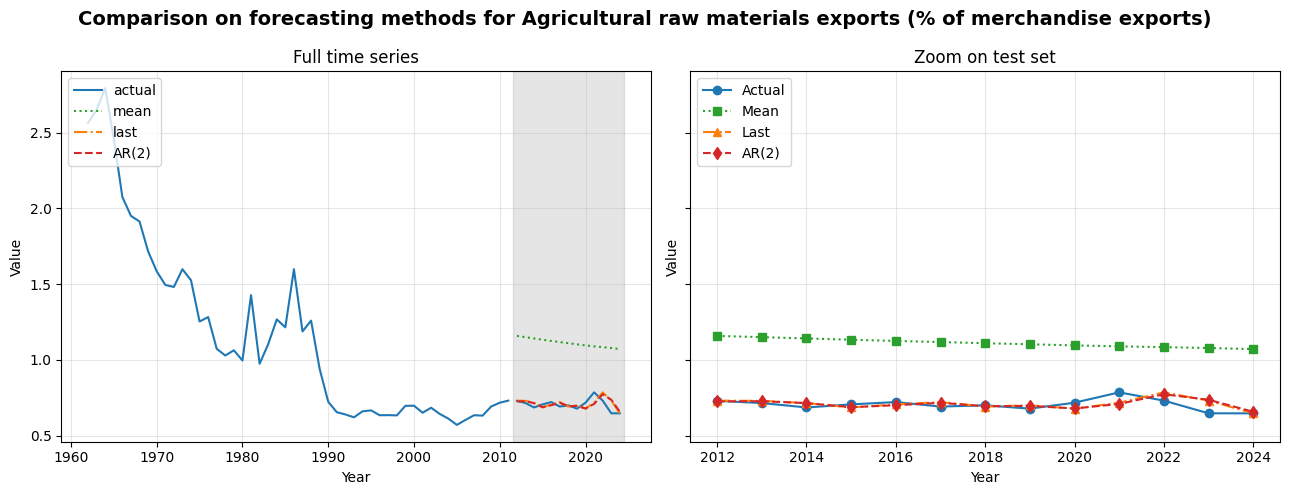


Indicator: Agricultural raw materials exports (% of merchandise exports)
    Year     Value  pred_mean  pred_last_value   pred_AR
50  2012  0.730070   1.158567         0.731385  0.726627
51  2013  0.715549   1.150165         0.730070  0.727549
52  2014  0.686465   1.141807         0.715549  0.715075
53  2015  0.706719   1.133216         0.686465  0.688271
54  2016  0.721962   1.125317         0.706719  0.701222
55  2017  0.692312   1.117984         0.721962  0.717207
56  2018  0.700483   1.110382         0.692312  0.694331
57  2019  0.678724   1.103191         0.700483  0.696915
58  2020  0.717790   1.095873         0.678724  0.679700
59  2021  0.786090   1.089465         0.717790  0.709635
60  2022  0.731626   1.084408         0.786090  0.773538
61  2023  0.647952   1.078625         0.731626  0.737455
62  2024  0.647641   1.071679         0.647952  0.658094
MAE -> mean: 0.407, last: 0.030, AR(2): 0.030
MSE -> mean: 0.168, last: 0.001, AR(2): 0.002


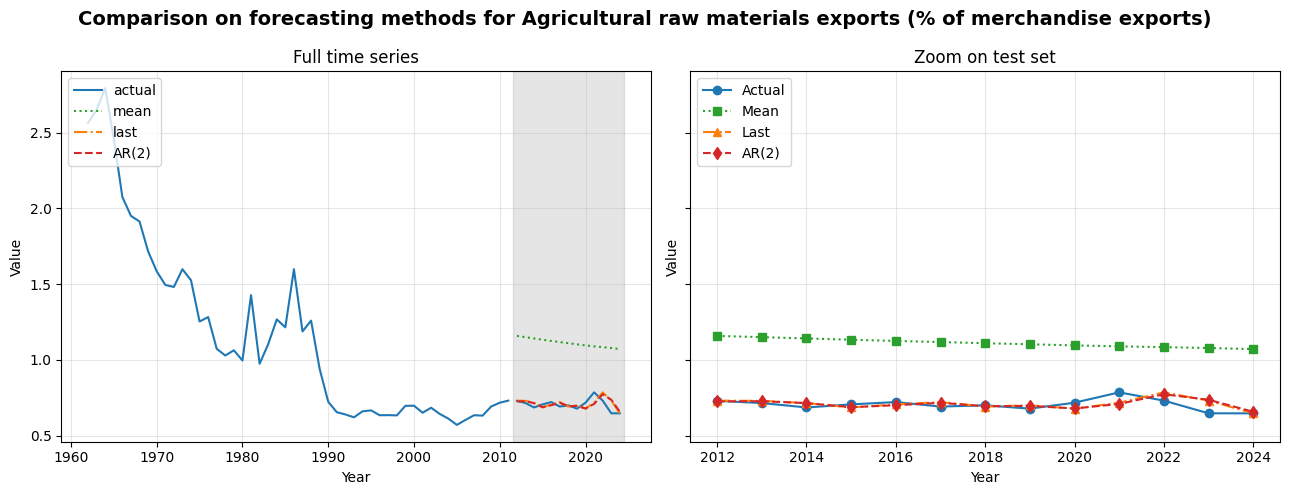


Indicator: Employment in agriculture (% of total employment) (modeled ILO estimate)
    Year     Value  pred_mean  pred_last_value   pred_AR
26  2017  3.782819   5.010655         3.884447  3.954057
27  2018  3.756879   4.965180         3.782819  3.720160
28  2019  3.889869   4.922026         3.756879  3.736875
29  2020  3.981957   4.886435         3.889869  3.958505
30  2021  4.050170   4.856286         3.981957  4.028065
31  2022  3.787698   4.830282         4.050170  4.083128
32  2023  3.594572   4.797701         3.787698  3.637381
MAE -> mean: 1.061, last: 0.125, AR(2): 0.106
MSE -> mean: 1.148, last: 0.021, AR(2): 0.021


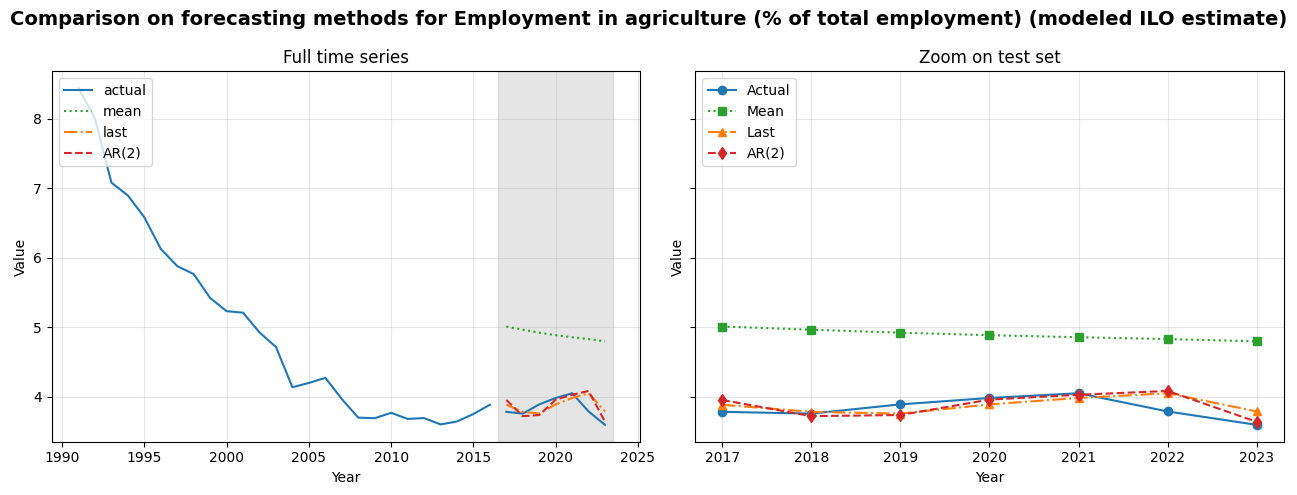


Indicator: Employment in agriculture, male (% of male employment) (modeled ILO estimate)
    Year     Value  pred_mean  pred_last_value   pred_AR
26  2017  4.814398   5.510566         4.863903  4.956692
27  2018  4.739735   5.484782         4.814398  4.781853
28  2019  4.985230   5.458173         4.739735  4.693282
29  2020  5.106434   5.441864         4.985230  5.112632
30  2021  5.191661   5.430683         5.106434  5.166871
31  2022  4.840262   5.422973         5.191661  5.232994
32  2023  4.626057   5.404763         4.840262  4.651680
MAE -> mean: 0.550, last: 0.163, AR(2): 0.132
MSE -> mean: 0.340, last: 0.037, AR(2): 0.038


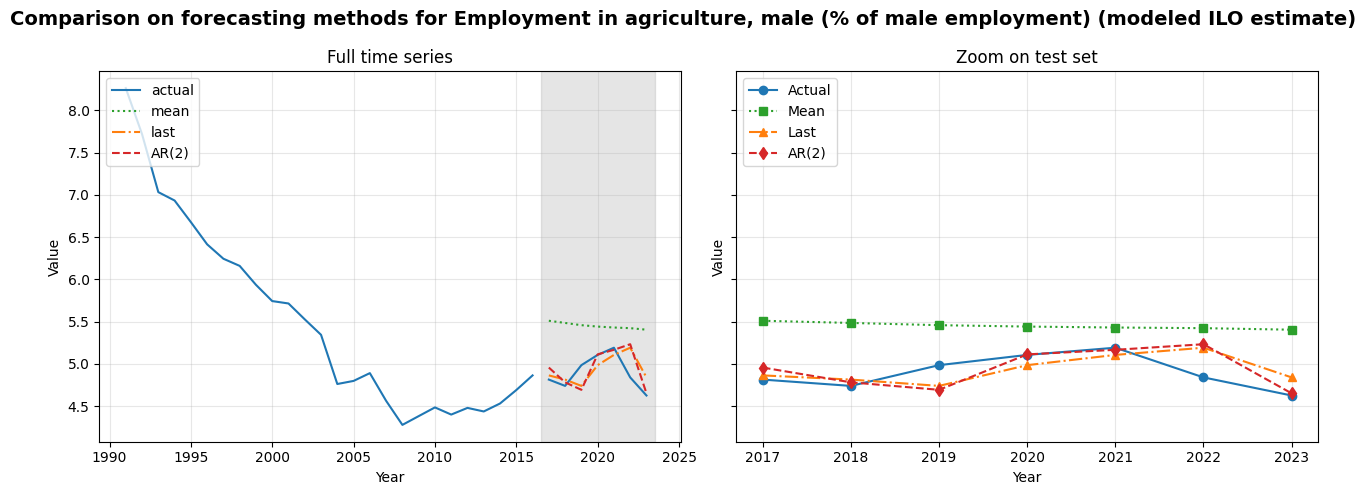


Indicator: Employment in agriculture, female (% of female employment) (modeled ILO estimate)
    Year     Value  pred_mean  pred_last_value   pred_AR
26  2017  2.350222   4.251096         2.517193  2.549459
27  2018  2.392978   4.180694         2.350222  2.260397
28  2019  2.378808   4.116847         2.392978  2.407329
29  2020  2.414602   4.056914         2.378808  2.365398
30  2021  2.468996   4.002170         2.414602  2.425931
31  2022  2.333656   3.952713         2.468996  2.489604
32  2023  2.182062   3.902118         2.333656  2.261231
MAE -> mean: 1.706, last: 0.086, AR(2): 0.098
MSE -> mean: 2.923, last: 0.011, AR(2): 0.013


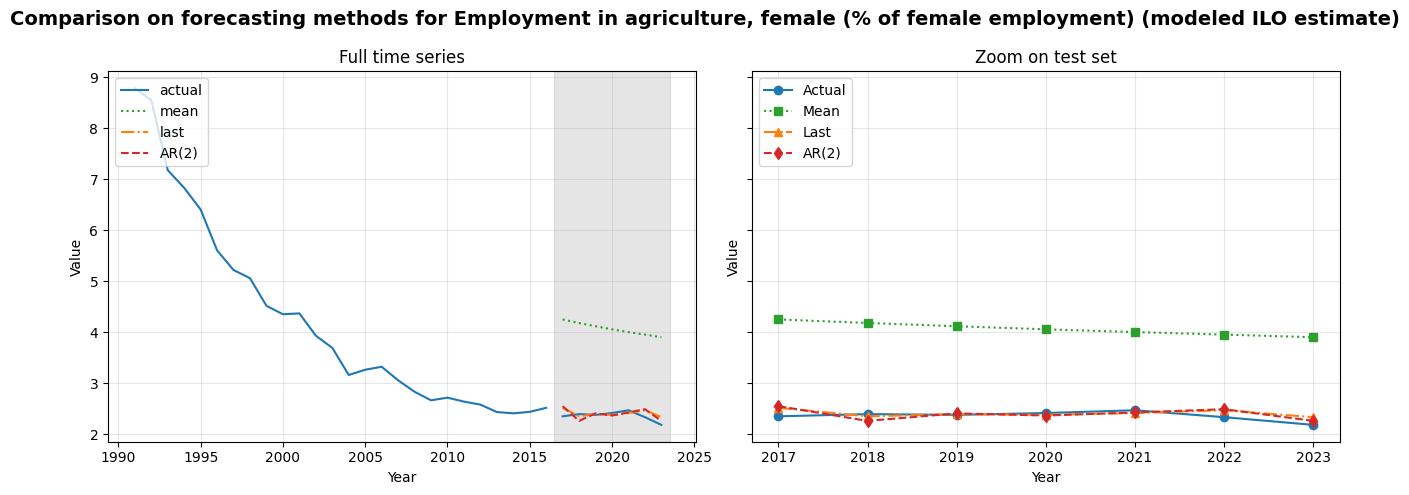


Indicator: Forest area (% of land area)
    Year      Value  pred_mean  pred_last_value    pred_AR
26  2016  31.620970  28.804963        31.439006  31.616087
27  2017  31.802934  28.909260        31.620970  31.798252
28  2018  31.984898  29.012605        31.802934  31.981688
29  2019  32.166970  29.115098        31.984898  32.162294
30  2020  32.348935  29.216827        32.166970  32.348766
31  2021  32.530899  29.317863        32.348935  32.523029
32  2022  32.712532  29.418271        32.530899  32.708557
MAE -> mean: 3.053, last: 0.182, AR(2): 0.004
MSE -> mean: 9.348, last: 0.033, AR(2): 0.000


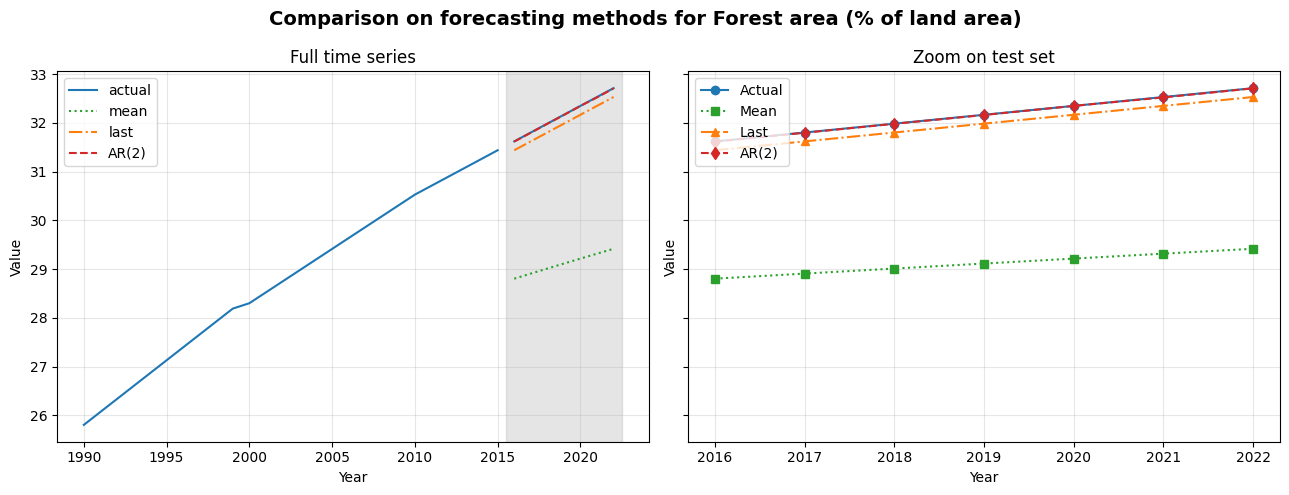

In [ ]:
import warnings
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters")
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    total_len = train_len + horizon

    if method == 'mean':
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df["Value"][:i])
            pred_mean.extend([mean] * window)
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = df["Value"][:i].iloc[-1]
            pred_last_value.extend([last_value] * window)
        return pred_last_value

    elif method == 'AR':
        pred_AR = []
        for i in range(train_len, total_len, window):
            # controllo: se non ci sono abbastanza osservazioni, salto
            if len(df["Value"][:i]) < 10:
                pred_AR.extend([np.nan] * window)
                continue
            try:
                model = SARIMAX(df["Value"][:i], order=(2,0,0))
                res = model.fit(disp=False)
                # print(f"AR params @ step {i}: {res.params}")
                predictions = res.get_prediction(start=i, end=i + window - 1)
                oos_pred = predictions.predicted_mean
                pred_AR.extend(oos_pred)
            except Exception as e:
                print(f"Errore AR per finestra {i}: {e}")
                pred_AR.extend([np.nan] * window)
        return pred_AR

indicators = ["Agricultural raw materials exports (% of merchandise exports)",
"Agricultural raw materials exports (% of merchandise exports)",
"Employment in agriculture (% of total employment) (modeled ILO estimate)",
"Employment in agriculture, male (% of male employment) (modeled ILO estimate)",
"Employment in agriculture, female (% of female employment) (modeled ILO estimate)",
"Forest area (% of land area)"]

for indicator in indicators:
    print(f"\n{'='*80}")
    print(f"Indicator: {indicator}")

    df_temp = (
        df[df["Indicator Name"] == indicator]
        .melt(id_vars=["Indicator Name"], var_name="Year", value_name="Value")
        .assign(Year=lambda d: d["Year"].astype(int))
        .dropna(subset=["Value"])
        [["Year", "Value"]]
        .reset_index(drop=True)
    )
    
    train = df_temp[:int(0.8*len(df_temp))]
    test = df_temp[int(0.8*len(df_temp)):]
    
    TRAIN_LEN = len(train)
    HORIZON = len(test)

    pred_mean = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'mean')
    pred_last_value = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'last')
    pred_AR = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'AR')

    test = df_temp.iloc[TRAIN_LEN:TRAIN_LEN+HORIZON].copy()
    test['pred_mean'] = pred_mean[:HORIZON]
    test['pred_last_value'] = pred_last_value[:HORIZON]
    test['pred_AR'] = pred_AR[:HORIZON]
    print(test)
    
    # mae e mse a confronto
    mae_mean = mean_absolute_error(test['Value'], test['pred_mean'])
    mae_last = mean_absolute_error(test['Value'], test['pred_last_value'])
    mae_ar = mean_absolute_error(test['Value'], test['pred_AR'])

    mse_mean = mean_squared_error(test['Value'], test['pred_mean'])
    mse_last = mean_squared_error(test['Value'], test['pred_last_value'])
    mse_ar = mean_squared_error(test['Value'], test['pred_AR'])
    
    print(f"MAE -> mean: {mae_mean:.3f}, last: {mae_last:.3f}, AR(2): {mae_ar:.3f}")
    print(f"MSE -> mean: {mse_mean:.3f}, last: {mse_last:.3f}, AR(2): {mse_ar:.3f}")
    
    # PLOT COMPARISON ON FORECASTING METHODS on stationary time series
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(13,5))
    fig.suptitle(f"Comparison on forecasting methods for {indicator}", fontsize=14, fontweight="bold")
    ax1.plot(train['Year'], train['Value'])
    ax1.plot(test['Year'], test['Value'], color = colors[0], linestyle='-', label='actual')
    ax1.plot(test['Year'], test['pred_mean'], color = colors[1], linestyle=':', label='mean')
    ax1.plot(test['Year'], test['pred_last_value'], color = colors[2], linestyle='-.', label='last')
    ax1.plot(test['Year'], test['pred_AR'], color = colors[3], linestyle='--', label='AR(2)')
    ax1.legend(loc=2)
    ax1.set_title("Full time series")
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Value')
    ax1.grid(True, alpha=0.3)
    start_year = int(test['Year'].iloc[0])
    end_year = int(test['Year'].iloc[-1])
    ax1.axvspan(start_year - 0.5, end_year + 0.5, color='#808080', alpha=0.2)
    
    ax2.plot(test['Year'], test['Value'], color = colors[0], linestyle='-', label='Actual', marker="o")
    ax2.plot(test['Year'], test['pred_mean'], color = colors[1], linestyle=':', label='Mean', marker="s")
    ax2.plot(test['Year'], test['pred_last_value'], color = colors[2], linestyle='-.', label='Last', marker="^")
    ax2.plot(test['Year'], test['pred_AR'], color = colors[3], linestyle='--', label='AR(2)', marker="d")
    ax2.legend(loc=2)
    ax2.set_title("Zoom on test set")
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Value')
    ax2.grid(True, alpha=0.3)
    
    # ax.set_xticks(range(0, len(df_temp), 5)) 
    # ax.set_xticklabels(df_temp['Year'][::5])
    
    ax1.tick_params(labelbottom=True)
    ax2.tick_params(labelbottom=True) 
    plt.setp(ax2.get_xticklabels(), visible=True)
    plt.tight_layout()
    plt.show()


Indicator: Rural population (% of total population)
Original data - Train: 52, Test: 13
Diff data - Train: 51, Test: 13


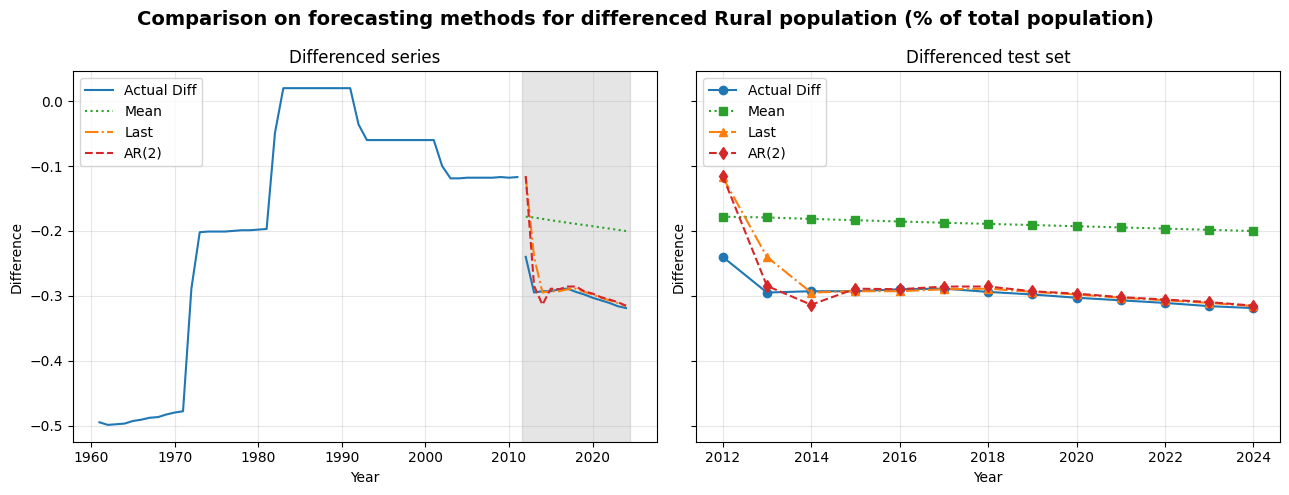

MAE livello originale -> mean: 0.719, last: 0.179, AR(2): 0.135
MSE livello originale -> mean: 0.683, last: 0.032, AR(2): 0.018


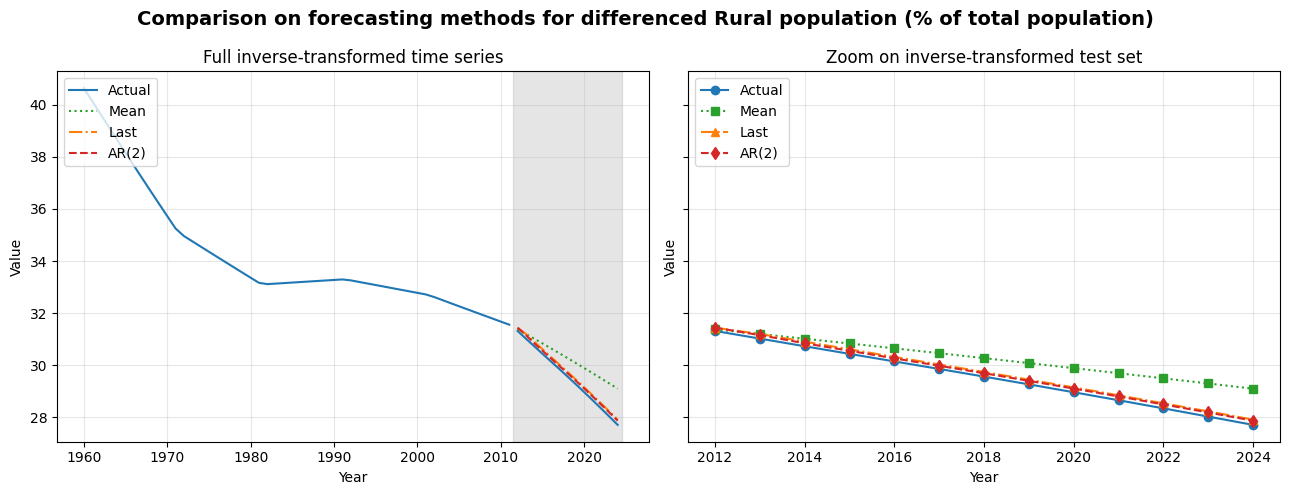


Indicator: Rural population
Original data - Train: 52, Test: 13
Diff data - Train: 51, Test: 13


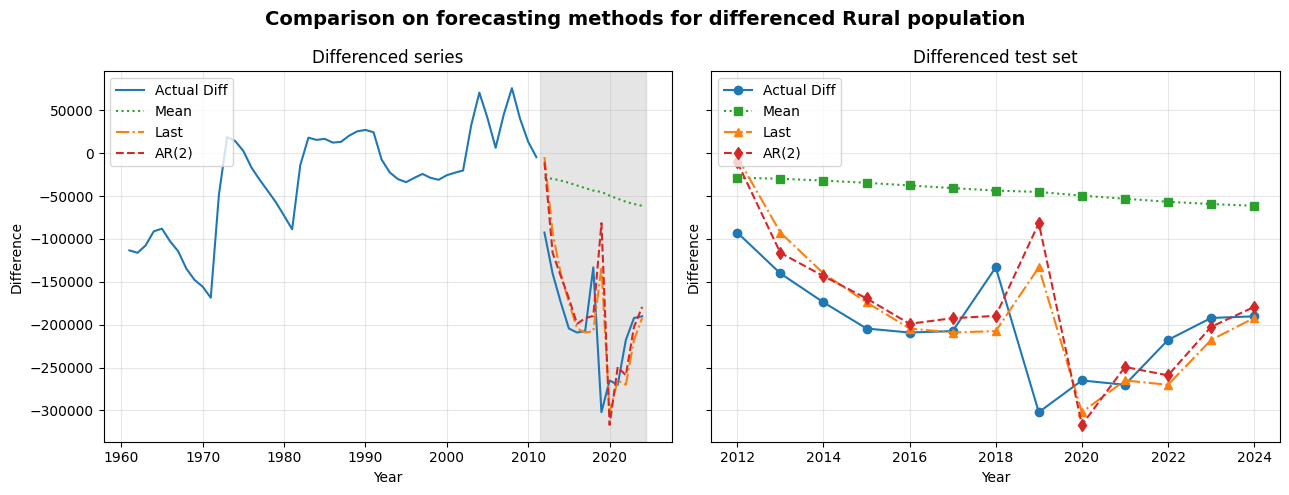

MAE livello originale -> mean: 1022047.961, last: 195332.308, AR(2): 220734.751
MSE livello originale -> mean: 1461795860902.569, last: 41265831409.231, AR(2): 56590421001.354


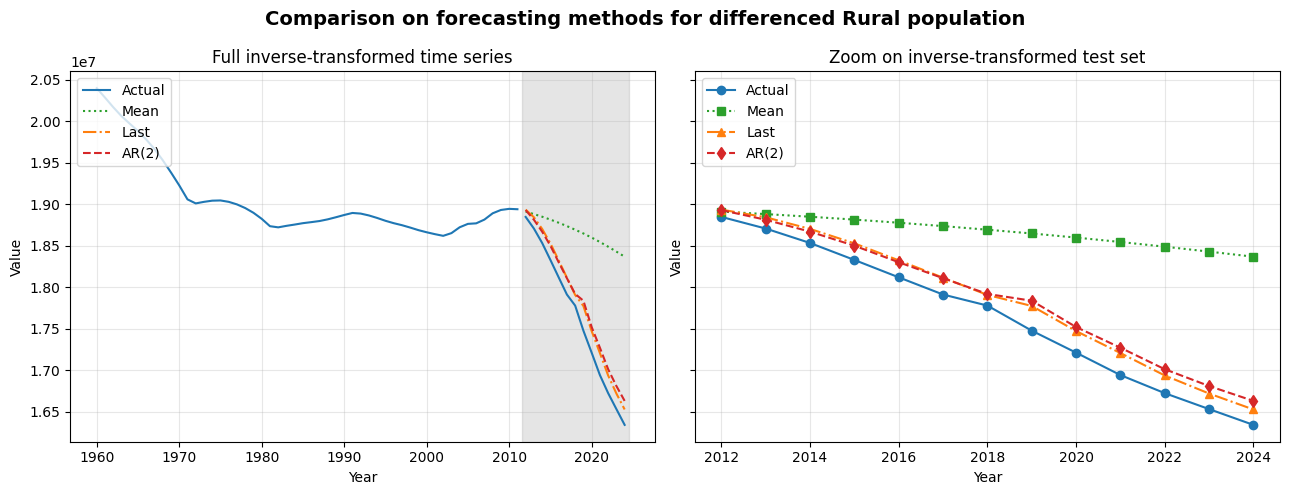


Indicator: Forest area (sq. km)
Original data - Train: 26, Test: 7
Diff data - Train: 25, Test: 7


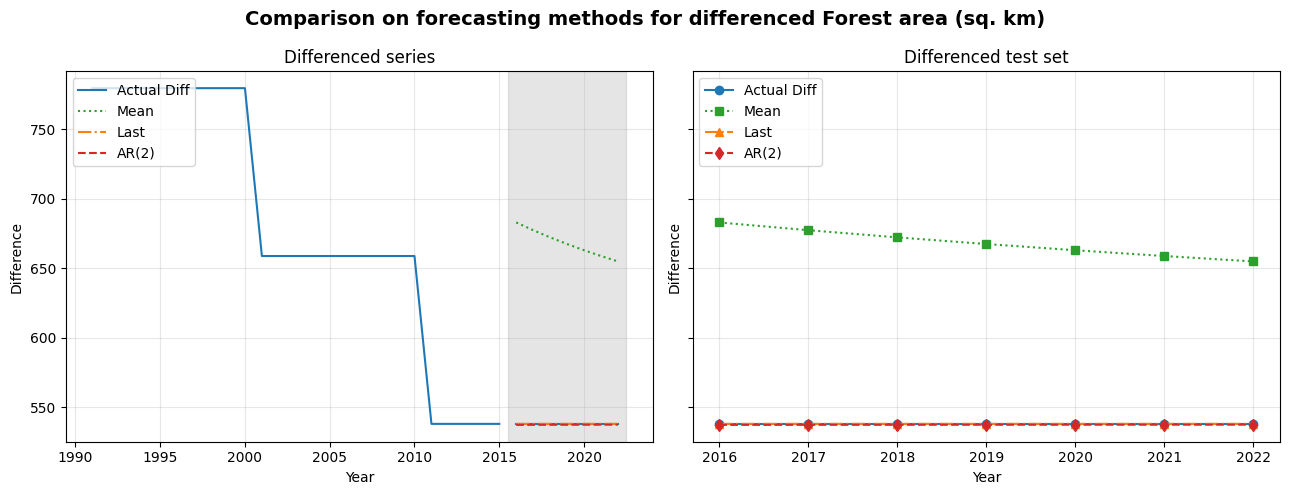

MAE livello originale -> mean: 538.560, last: 0.020, AR(2): 2.720
MSE livello originale -> mean: 355029.962, last: 0.000, AR(2): 9.027


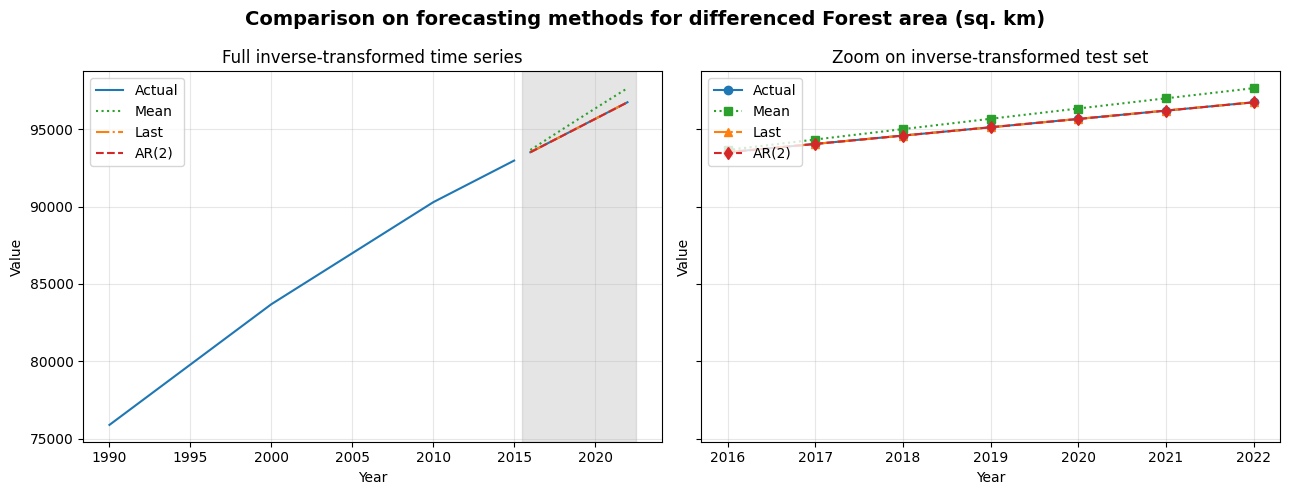

In [ ]:
import warnings
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters")
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    total_len = train_len + horizon

    if method == 'mean':
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df["Diff"][:i].values)
            pred_mean.extend([mean] * window)
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = df["Diff"][:i].iloc[-1]
            pred_last_value.extend([last_value] * window)
        return pred_last_value

    elif method == 'AR':
        pred_AR = []
        for i in range(train_len, total_len, window):
            # controllo: se non ci sono abbastanza osservazioni, salto
            if len(df["Diff"][:i]) < 12:
                pred_AR.extend([np.nan] * window)
                continue
            try:
                model = SARIMAX(df["Diff"][:i].values, order=(2,0,0))
                res = model.fit(disp=False)
                # print(f"AR params @ step {i}: {res.params}")
                predictions = res.get_prediction(start=i, end=i + window - 1)
                oos_pred = predictions.predicted_mean
                pred_AR.extend(oos_pred)
            except Exception as e:
                print(f"Errore AR per finestra {i}: {e}")
                pred_AR.extend([np.nan] * window)
        return pred_AR

indicators = ["Rural population (% of total population)",
"Rural population",
"Forest area (sq. km)"]

for indicator in indicators:
    print(f"\n{'='*80}")
    print(f"Indicator: {indicator}")

    df_temp = (
        df[df["Indicator Name"] == indicator]
        .melt(id_vars=["Indicator Name"], var_name="Year", value_name="Value")
        .assign(Year=lambda d: d["Year"].astype(int))
        .dropna(subset=["Value"])
        [["Year", "Value"]]
        .reset_index(drop=True)
    )

    split_idx = int(0.8*len(df_temp))
    train_original = df_temp.iloc[:split_idx]
    test_original = df_temp.iloc[split_idx:]
    last_train_value = train_original['Value'].iloc[-1]

    df_temp['Diff'] = df_temp['Value'].diff()
    df_temp = df_temp.dropna(subset=['Diff']).reset_index(drop=True)
    # Dopo differenziazione, gli indici cambiano
    # Il train ora va da 0 a split_idx-2 (perché perdiamo il primo elemento per diff)
    train_len_diff = split_idx - 1
    train = df_temp.iloc[:train_len_diff]
    test = df_temp.iloc[train_len_diff:]

    TRAIN_LEN = len(train)
    HORIZON = len(test)

    print(f"Original data - Train: {len(train_original)}, Test: {len(test_original)}")
    print(f"Diff data - Train: {TRAIN_LEN}, Test: {HORIZON}")

    pred_mean = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'mean')
    pred_last_value = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'last')
    pred_AR = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'AR')

    test_results = test.copy()
    test_results['pred_mean'] = pred_mean[:HORIZON]
    test_results['pred_last_value'] = pred_last_value[:HORIZON]
    test_results['pred_AR'] = pred_AR[:HORIZON]
    
    # Inverse transformation per tornare ai livelli originali
    test_results['pred_mean_levels'] = last_train_value + np.cumsum(test_results['pred_mean'])
    test_results['pred_last_value_levels'] = last_train_value + np.cumsum(test_results['pred_last_value'])
    test_results['pred_AR_levels'] = last_train_value + np.cumsum(test_results['pred_AR'])
    
    # Allinea con i valori originali del test set
    # I valori originali del test set iniziano da split_idx
    test_actual_values = test_original['Value'].values
    
    # test = df_temp.iloc[TRAIN_LEN:TRAIN_LEN+HORIZON].copy()
    # test['pred_mean'] = pred_mean[:HORIZON]
    # test['pred_last_value'] = pred_last_value[:HORIZON]
    # test['pred_AR'] = pred_AR[:HORIZON]
    # print(test)
    
    # PLOT COMPARISON ON FORECASTING METHODS on differenced time series
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(13,5))
    fig.suptitle(f"Comparison on forecasting methods for differenced {indicator}", fontsize=14, fontweight="bold")
    ax1.plot(train['Year'], train['Diff'])
    ax1.plot(test_results['Year'], test_results['Diff'], color = colors[0], linestyle='-', label='Actual Diff')
    ax1.plot(test_results['Year'], test_results['pred_mean'], color = colors[1], linestyle=':', label='Mean')
    ax1.plot(test_results['Year'], test_results['pred_last_value'], color = colors[2], linestyle='-.', label='Last')
    ax1.plot(test_results['Year'], test_results['pred_AR'], color = colors[3], linestyle='--', label='AR(2)')
    ax1.legend(loc=2)
    ax1.set_title("Differenced series")
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Difference')
    ax1.grid(True, alpha=0.3)
    start_year = int(test['Year'].iloc[0])
    end_year = int(test['Year'].iloc[-1])
    ax1.axvspan(start_year - 0.5, end_year + 0.5, color='#808080', alpha=0.2)
    
    ax2.plot(test_results['Year'], test_results['Diff'], color = colors[0], linestyle='-', label='Actual Diff', marker='o')
    ax2.plot(test_results['Year'], test_results['pred_mean'], color = colors[1], linestyle=':', label='Mean', marker='s')
    ax2.plot(test_results['Year'], test_results['pred_last_value'], color = colors[2], linestyle='-.', label='Last', marker='^')
    ax2.plot(test_results['Year'], test_results['pred_AR'], color = colors[3], linestyle='--', label='AR(2)', marker='d')
    ax2.legend(loc=2)
    ax2.set_title("Differenced test set")
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Difference')
    ax2.grid(True, alpha=0.3)
    
    ax1.tick_params(labelbottom=True)
    ax2.tick_params(labelbottom=True) 
    plt.setp(ax2.get_xticklabels(), visible=True)
    plt.tight_layout()
    plt.show()

    valid_idx = ~np.isnan(test_results['pred_AR_levels'])
    if np.sum(valid_idx) > 0:
        test_valid = test_results[valid_idx]
        actual_values_valid = test_actual_values[valid_idx]
        
        mae_mean = mean_absolute_error(actual_values_valid, test_valid['pred_mean_levels'])
        mae_last = mean_absolute_error(actual_values_valid, test_valid['pred_last_value_levels'])
        mae_ar = mean_absolute_error(actual_values_valid, test_valid['pred_AR_levels'])

        mse_mean = mean_squared_error(actual_values_valid, test_valid['pred_mean_levels'])
        mse_last = mean_squared_error(actual_values_valid, test_valid['pred_last_value_levels'])
        mse_ar = mean_squared_error(actual_values_valid, test_valid['pred_AR_levels'])
        
        print(f"MAE livello originale -> mean: {mae_mean:.3f}, last: {mae_last:.3f}, AR(2): {mae_ar:.3f}")
        print(f"MSE livello originale -> mean: {mse_mean:.3f}, last: {mse_last:.3f}, AR(2): {mse_ar:.3f}")

    # test['pred_mean_levels'] = np.cumsum(test['pred_mean']) + last_train_value
    # test['pred_last_value_levels'] = np.cumsum(test['pred_last_value']) + last_train_value
    # test['pred_AR_levels'] = np.cumsum(test['pred_AR']) + last_train_value
    
    # # mae e mse a confronto
    # mae_mean = mean_absolute_error(test['Value'], test['pred_mean_levels'])
    # mae_last = mean_absolute_error(test['Value'], test['pred_last_value_levels'])
    # mae_ar = mean_absolute_error(test['Value'], test['pred_AR_levels'])

    # mse_mean = mean_squared_error(test['Value'], test['pred_mean_levels'])
    # mse_last = mean_squared_error(test['Value'], test['pred_last_value_levels'])
    # mse_ar = mean_squared_error(test['Value'], test['pred_AR_levels'])
    
    # print(f"MAE livello originale -> mean: {mae_mean:.3f}, last: {mae_last:.3f}, AR(2): {mae_ar:.3f}")
    # print(f"MSE livello originale -> mean: {mse_mean:.3f}, last: {mse_last:.3f}, AR(2): {mse_ar:.3f}")
    
    # PLOT COMPARISON ON FORECASTING METHODS on inverse-trasnformed time series
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(13,5))
    fig.suptitle(f"Comparison on forecasting methods for differenced {indicator}", fontsize=14, fontweight="bold")
    ax1.plot(train_original['Year'], train_original['Value'])
    ax1.plot(test_original['Year'], test_original['Value'], color = colors[0], linestyle='-', label='Actual')
    ax1.plot(test_valid['Year'], test_valid['pred_mean_levels'], color = colors[1], linestyle=':', label='Mean')
    ax1.plot(test_valid['Year'], test_valid['pred_last_value_levels'], color = colors[2], linestyle='-.', label='Last')
    ax1.plot(test_valid['Year'], test_valid['pred_AR_levels'], color = colors[3], linestyle='--', label='AR(2)')
    ax1.legend(loc=2)
    ax1.set_title("Full inverse-transformed time series")
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Value')
    ax1.grid(True, alpha=0.3)
    start_year = int(test['Year'].iloc[0])
    end_year = int(test['Year'].iloc[-1])
    ax1.axvspan(start_year - 0.5, end_year + 0.5, color='#808080', alpha=0.2)
    
    ax2.plot(test_original['Year'], test_original['Value'], color = colors[0], linestyle='-', label='Actual', marker='o')
    ax2.plot(test_valid['Year'], test_valid['pred_mean_levels'], color = colors[1], linestyle=':', label='Mean', marker='s')
    ax2.plot(test_valid['Year'], test_valid['pred_last_value_levels'], color = colors[2], linestyle='-.', label='Last', marker='^')
    ax2.plot(test_valid['Year'], test_valid['pred_AR_levels'], color = colors[3], linestyle='--', label='AR(2)', marker='d')
    ax2.legend(loc=2)
    ax2.set_title("Zoom on inverse-transformed test set")
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Value')
    ax2.grid(True, alpha=0.3)
    
    ax1.tick_params(labelbottom=True)
    ax2.tick_params(labelbottom=True) 
    plt.setp(ax2.get_xticklabels(), visible=True)
    plt.tight_layout()
    plt.show()